Part B: Dataset Understanding & Preparation

* Dataset loading

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('Advanced_Regression_HousePrice_Dataset_3800.csv')
df.head(7)

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429
5,200006,2017-09-01,2555,5,3,3.2,25,20.6,0,0,5.63,19298164
6,200007,2017-03-01,2460,6,5,9.0,20,6.9,0,1,4.86,42510938


Target variable- HousepriceINR

* Identify null values

In [24]:
df.isnull().sum()

property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64

* Data statistics

In [25]:
df.describe()

,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
count,3800.00000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3.800000e+03
mean,201900.50000,1716.925526,3.428158,2.916316,6.502237,22.537105,13.085132,0.548421,0.472895,4.242911,2.071940e+07
std,1097.10984,582.996559,1.356682,1.133540,1.766945,12.325740,6.537425,0.497715,0.499330,2.045371,8.707465e+06
min,200001.00000,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.500000,1.506126e+06
25%,200950.75000,1322.000000,2.000000,2.000000,5.300000,14.000000,8.500000,0.000000,0.000000,2.810000,1.446895e+07
50%,201900.50000,1700.500000,3.000000,3.000000,6.500000,20.000000,13.000000,1.000000,0.000000,4.220000,1.989180e+07
75%,202850.25000,2105.000000,4.000000,4.000000,7.700000,29.000000,17.500000,1.000000,1.000000,5.650000,2.596062e+07
max,203800.00000,3776.000000,7.000000,6.000000,10.000000,80.000000,38.700000,1.000000,1.000000,12.000000,5.930315e+07


Identifying distribution

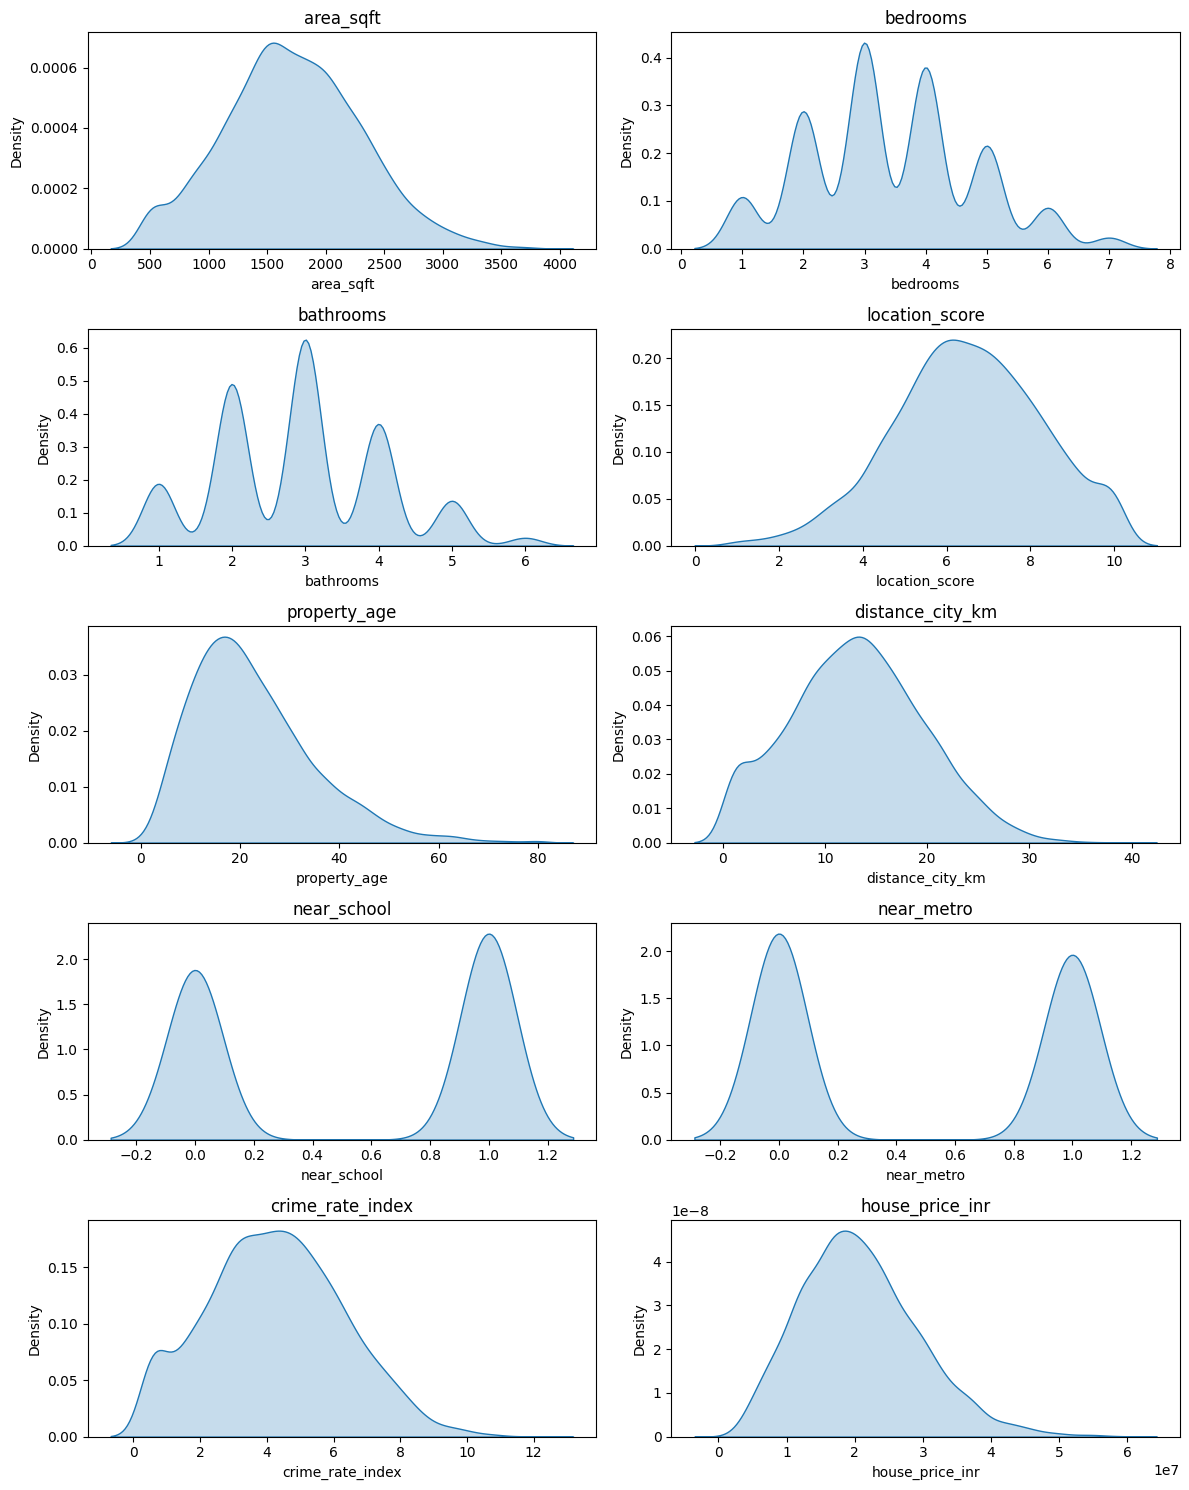

In [26]:
cols=['area_sqft','bedrooms','bathrooms','location_score','property_age','distance_city_km','near_school','near_metro','crime_rate_index','house_price_inr']

fig, axes = plt.subplots(5, 2, figsize=(12, 15))

for ax, col in zip(axes.ravel(), cols):
    sns.kdeplot(df[col], ax=ax, fill=True)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Finding outliers

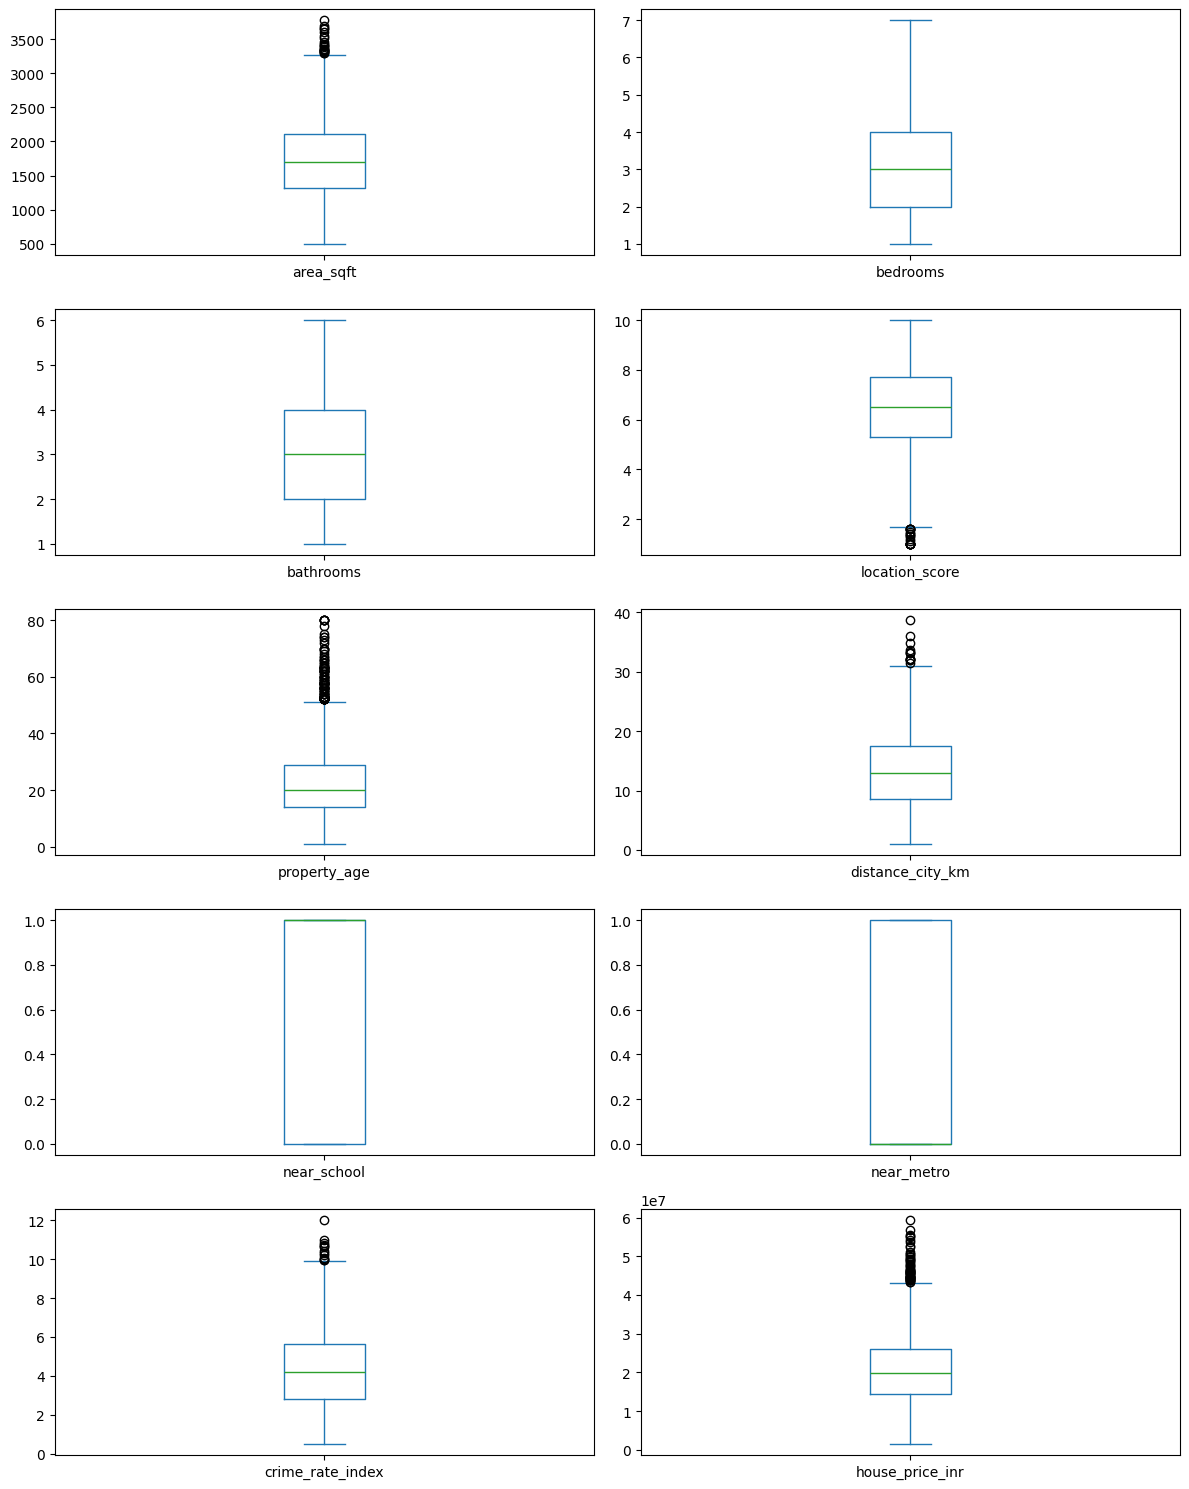

In [27]:
df[cols].plot(kind='box', subplots=True, layout=(5,2),figsize=(12,15), sharex=False, sharey=False)

plt.tight_layout()
plt.show()

Remove outliers using IQR

In [28]:
cols2 = ['area_sqft','location_score','property_age','distance_city_km','crime_rate_index','house_price_inr']
print("Original shape:", df[cols2].shape)

for col in cols2:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("After outlier removal:", df[cols2].shape)

Original shape: (3800, 6)
After outlier removal: (3589, 6)


After outliers removal

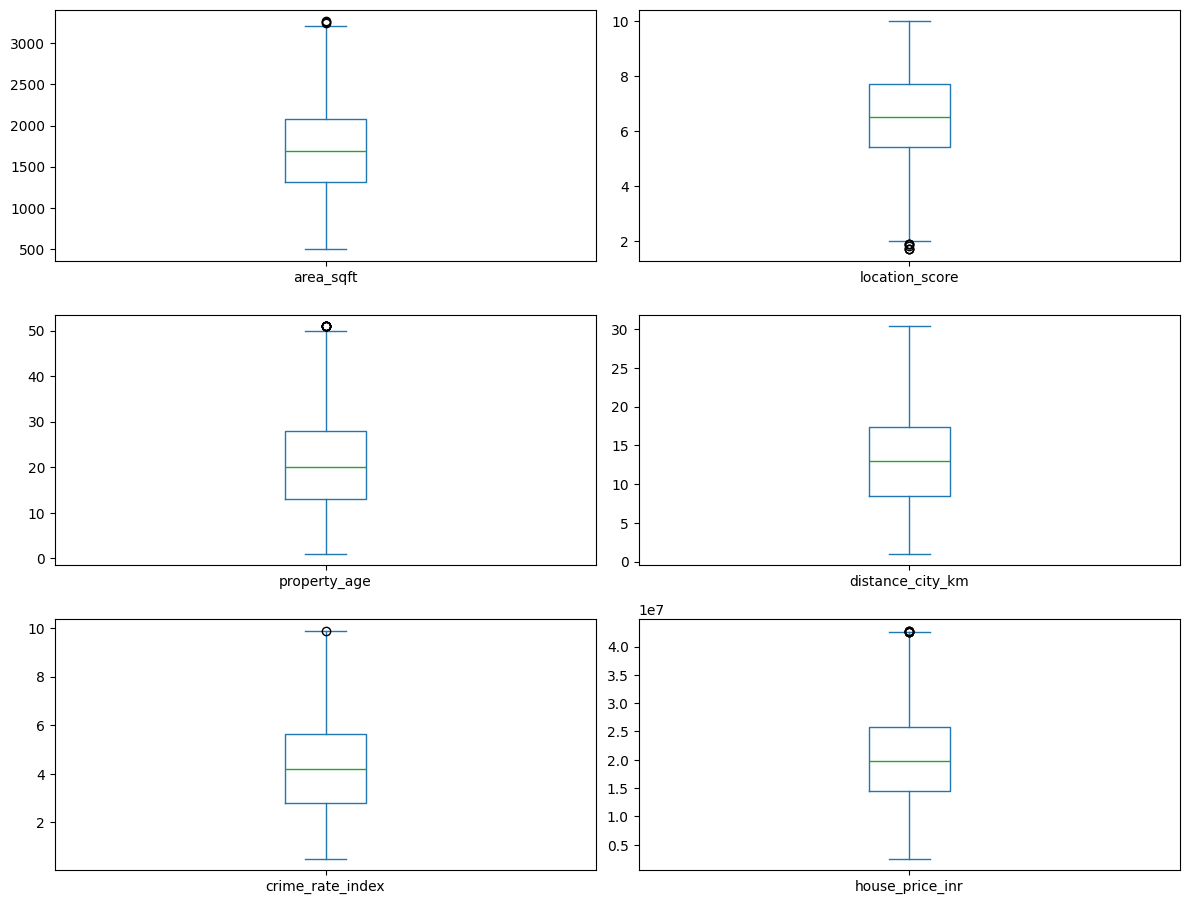

In [29]:
df[cols2].plot(kind='box', subplots=True, layout=(5,2),figsize=(12,15), sharex=False)

plt.tight_layout()
plt.show()

In [30]:
df.info()
# df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 3589 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3589 non-null   int64  
 1   sale_date         3589 non-null   object 
 2   area_sqft         3589 non-null   int64  
 3   bedrooms          3589 non-null   int64  
 4   bathrooms         3589 non-null   int64  
 5   location_score    3589 non-null   float64
 6   property_age      3589 non-null   int64  
 7   distance_city_km  3589 non-null   float64
 8   near_school       3589 non-null   int64  
 9   near_metro        3589 non-null   int64  
 10  crime_rate_index  3589 non-null   float64
 11  house_price_inr   3589 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 364.5+ KB


In [31]:
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:", list(cat_cols))
print("Numerical Columns:", list(num_cols))

Categorical Columns: ['sale_date']
Numerical Columns: ['property_id', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index', 'house_price_inr']


Perform scaling

In [32]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['area_sqft','location_score','property_age','distance_city_km','crime_rate_index']
scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print(df.head())

   property_id   sale_date  area_sqft  bedrooms  bathrooms  location_score  \
0       200001  2014-01-01   0.876693         6          4        0.925295   
1       200002  2019-12-01   1.238767         5          4       -0.704701   
2       200003  2016-10-01  -1.155940         3          3       -0.355416   
3       200004  2013-03-01   0.109526         4          3        0.284939   
4       200005  2013-07-01   0.064715         4          4        2.031364   

   property_age  distance_city_km  near_school  near_metro  crime_rate_index  \
0     -0.038259         -1.447797            0           0          0.303668   
1      0.619638         -0.330404            1           1         -0.664835   
2     -1.354054          2.282091            0           1         -0.093667   
3      0.525653         -0.141549            0           0         -0.471135   
4      0.995579         -1.825507            0           1         -0.193000   

   house_price_inr  
0         35154898  
1       

In [33]:
print(df[scale_cols].describe())

          area_sqft  location_score  property_age  distance_city_km  \
count  3.589000e+03    3.589000e+03  3.589000e+03      3.589000e+03   
mean   1.846144e-16    8.948602e-16  2.177757e-17     -7.721139e-17   
std    1.000139e+00    1.000139e+00  1.000139e+00      1.000139e+00   
min   -2.136407e+00   -2.800410e+00 -1.917965e+00     -1.888459e+00   
25%   -6.863190e-01   -6.464867e-01 -7.901417e-01     -7.081144e-01   
50%   -1.056738e-02   -6.131219e-03 -1.322446e-01      9.208592e-05   
75%    6.974482e-01    6.924384e-01  6.196379e-01      6.925607e-01   
max    2.823288e+00    2.031364e+00  2.781300e+00      2.738491e+00   

       crime_rate_index  
count      3.589000e+03  
mean       5.592876e-17  
std        1.000139e+00  
min       -1.851873e+00  
25%       -7.045690e-01  
50%       -9.233134e-03  
75%        7.010028e-01  
max        2.811844e+00  


Apply linear regression

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import numpy as np

X = df.drop(columns=['house_price_inr','sale_date','property_id'])
y = df['house_price_inr']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print('X_test shape: ',X_test.shape,'\n','y_test shape: ',y_test.shape,'\n')
print("R² Score :", round(r2, 4),'\n','MAE: ', round(mae, 2),'\n','MSE:', round(mse, 2),'\n','RMSE:', round(rmse, 2))

X_test shape:  (718, 9) 
 y_test shape:  (718,) 

R² Score : 0.9102 
 MAE:  1876064.29 
 MSE: 5861971811875.94 
 RMSE: 2421150.93


Part C: Regularized Linear Models

In [35]:
from sklearn.linear_model import Ridge
import numpy as np

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

print(f"R2 Score : {r2_score(y_test, y_pred_ridge)}\nRMSE : {np.sqrt(mean_squared_error(y_test, y_pred_ridge))}")

R2 Score : 0.9102059613069012
RMSE : 2421662.660280546


In [36]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print(f"R2 Score : {r2_score(y_test, y_pred_lasso)}\nRMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lasso))}")

R2 Score : 0.9102439037585879
RMSE : 2421150.969703701


In [37]:
from sklearn.linear_model import RidgeCV

alphas = [0.001,0.01,0.1,1,10,100]
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)

print("Best Alpha:", ridge_cv.alpha_)

ridge_best = Ridge(alpha=ridge_cv.alpha_)
ridge_best.fit(X_train, y_train)
y_pred_ridge = ridge_best.predict(X_test)

print("R2:", r2_score(y_test, y_pred_ridge))

Best Alpha: 0.1
R2: 0.9102401324532371


In [38]:
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(alphas=[0.001,0.01,0.1,1,10,100],cv=5,random_state=42)
lasso_cv.fit(X_train, y_train)

print("Best Alpha:", lasso_cv.alpha_)

lasso_best = Lasso(alpha=lasso_cv.alpha_)

lasso_best.fit(X_train, y_train)
y_pred_lasso = lasso_best.predict(X_test)
print("R2:", r2_score(y_test, y_pred_lasso))

Best Alpha: 100.0
R2: 0.9102435713272488


Compare training error

In [39]:
from sklearn.metrics import mean_squared_error

ridge_train_pred = ridge_best.predict(X_train)
lasso_train_pred = lasso_best.predict(X_train)

ridge_train_rmse = np.sqrt(mean_squared_error(y_train, ridge_train_pred))
lasso_train_rmse = np.sqrt(mean_squared_error(y_train, lasso_train_pred))

print("Ridge Train RMSE :", ridge_train_rmse)
print("Lasso Train RMSE :", lasso_train_rmse)

Ridge Train RMSE : 2358648.4599213866
Lasso Train RMSE : 2358648.4490861935


Feature coefficients

In [40]:
import pandas as pd

comparison = pd.DataFrame({"Feature": X.columns,"Ridge": ridge_best.coef_,"Lasso": lasso_best.coef_})
print(comparison)

            Feature         Ridge         Lasso
0         area_sqft  6.422995e+06  6.423572e+06
1          bedrooms  3.226839e+05  3.223225e+05
2         bathrooms  1.898893e+05  1.898098e+05
3    location_score  3.521520e+06  3.521673e+06
4      property_age -5.939903e+05 -5.939000e+05
5  distance_city_km -3.308899e+04 -3.288755e+04
6       near_school  8.293734e+04  8.252424e+04
7        near_metro  9.300003e+04  9.261081e+04
8  crime_rate_index -1.361791e+05 -1.360829e+05


Part D: Cross-Validation Strategies

* K-fold

In [41]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

X = df.drop(columns=['house_price_inr','sale_date'], axis=1)
y = df['house_price_inr']

model = LinearRegression()

kfold = KFold(n_splits=5,shuffle=True,random_state=42)
scores = cross_val_score(model,X,y,cv=kfold,scoring='r2')

print("K-Fold R² Scores:", scores)
print("Mean :", np.mean(scores))

K-Fold R² Scores: [0.91044282 0.91342864 0.91504389 0.91698602 0.90885125]
Mean : 0.912950524717852


* Leave one out

In [ ]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()
model = LinearRegression()

scores = cross_val_score(model,X,y,cv=loo,scoring='r2')
print("Number of Splits:", len(scores))
print("Mean Score:", np.mean(scores))

* TimeSeriesSplit

In [80]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)
scores = []

for train_idx, test_idx in tscv.split(X):

    X_train_ts = X.iloc[train_idx]
    X_test_ts = X.iloc[test_idx]

    y_train_ts = y.iloc[train_idx]
    y_test_ts = y.iloc[test_idx]

    model = LinearRegression()
    model.fit(X_train_ts, y_train_ts)

    y_pred = model.predict(X_test_ts)
    scores.append(r2_score(y_test_ts, y_pred))

print("Time Series Scores:", scores)
print("Mean :", np.mean(scores))


Time Series Scores: [0.9052165267707456, 0.9174690912202715, 0.914710344579734, 0.9001488572902901, 0.9141832980254796]
Mean : 0.9103456235773042


Part E: Tree-Based Regression Models

Decision tree

In [44]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("R² :", r2_score(y_test, y_pred_dt))
print("MAE :", mean_absolute_error(y_test, y_pred_dt))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

R² : 0.8457127510096888
MAE : 2381779.745819398
RMSE : 3128357.894798327


* Using hyperparameters

In [46]:
dt_depth = DecisionTreeRegressor(max_depth=5,min_samples_split=10,random_state=42)

dt_depth.fit(X_train, y_train)
y_pred = dt_depth.predict(X_test)

print("R²:", r2_score(y_test, y_pred))

R²: 0.8778679459107375


Implement random forest

In [47]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100,random_state=42)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("R² Score :", r2_score(y_test, y_pred_rf))
print("MAE      :", mean_absolute_error(y_test, y_pred_rf))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

R² Score : 0.9194109948807202
MAE      : 1725090.0572575252
RMSE     : 2260941.427064357


Part F: Support Vector Regression

* Linear

In [48]:
from sklearn.svm import SVR

svr_linear = SVR(kernel='linear')
svr_linear.fit(X_train, y_train)
y_pred_linear = svr_linear.predict(X_test)

print("R² Score :", r2_score(y_test, y_pred_linear))
print("MAE :", mean_absolute_error(y_test, y_pred_linear))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_linear)))

R² Score : 0.001331673990427995
MAE : 6538708.5657617245
RMSE : 7959065.013249021


* Rbf

In [51]:
svr_linear = SVR(kernel='linear')

svr_linear.fit(X_train, y_train)

y_pred_rbf = svr_linear.predict(X_test)

print("R² Score :", r2_score(y_test, y_pred_rbf))
print("MAE :", mean_absolute_error(y_test, y_pred_rbf))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_rbf)))

R² Score : 0.001331673990427995
MAE : 6538708.5657617245
RMSE : 7959065.013249021
